In [1]:
import pandas as pd
import os

In [2]:
from google.colab import files

uploaded = files.upload()

Saving smoke_detection_iot.csv to smoke_detection_iot.csv


In [3]:
import pandas as pd

df = pd.read_csv("smoke_detection_iot.csv")

In [4]:
df.head()

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,4,0


In [5]:
df = df.drop(columns=["Unnamed: 0", "UTC"])

In [6]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)

In [7]:
print("Shape of data:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

Shape of data: (62630, 14)

Missing values:
 Temperature_C_    0
Humidity_         0
TVOC_ppb_         0
eCO2_ppm_         0
Raw_H2            0
Raw_Ethanol       0
Pressure_hPa_     0
PM1_0             0
PM2_5             0
NC0_5             0
NC1_0             0
NC2_5             0
CNT               0
Fire_Alarm        0
dtype: int64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

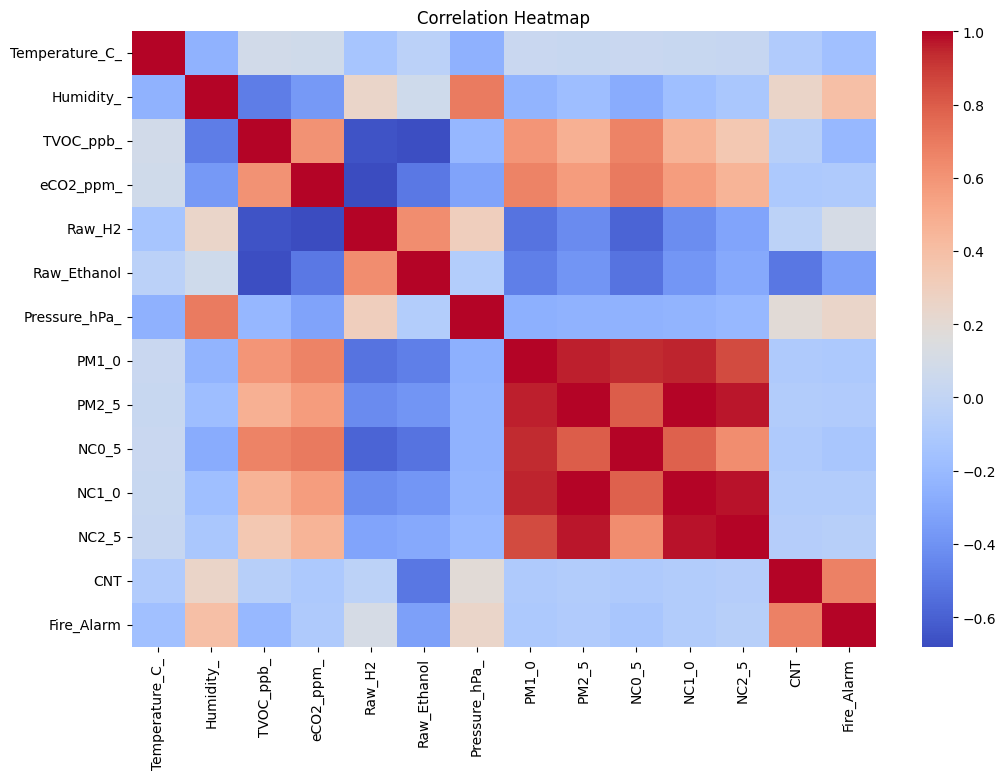

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [10]:
df.corr()["Fire_Alarm"].sort_values(ascending=False)

,Fire_Alarm
Fire_Alarm,1.000000
CNT,0.673762
Humidity_,0.399846
Pressure_hPa_,0.249797
Raw_H2,0.107007
NC2_5,-0.057707
NC1_0,-0.082828
PM2_5,-0.084916
eCO2_ppm_,-0.097006
PM1_0,-0.110552


In [11]:
X = df.drop(columns=["Fire_Alarm"])
y = df["Fire_Alarm"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (50104, 13)
X_test shape: (12526, 13)
y_train shape: (50104,)
y_test shape: (12526,)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

X_train_scaled.head()

,Temperature_C_,Humidity_,TVOC_ppb_,eCO2_ppm_,Raw_H2,Raw_Ethanol,Pressure_hPa_,PM1_0,PM2_5,NC0_5,NC1_0,NC2_5,CNT
0,0.102304,0.380413,-0.104938,-0.140638,-0.141244,-0.497961,0.058173,-0.106924,-0.092413,-0.111938,-0.091093,-0.074202,0.957062
1,-1.577382,0.827065,-0.222397,-0.140638,0.773316,0.513611,0.739178,-0.108351,-0.093101,-0.114065,-0.091726,-0.074231,-0.516126
2,0.765904,-0.094579,-0.078248,-0.137486,0.065269,-0.581984,0.058928,-0.106762,-0.092338,-0.111696,-0.091021,-0.074198,1.460179
3,0.619645,0.414422,-0.094881,-0.134335,-0.218687,-0.519379,0.101208,-0.107238,-0.092569,-0.112407,-0.091233,-0.074208,0.767966
4,0.466351,-0.914197,-0.240447,-0.140638,-0.395698,1.581199,-0.821394,-0.106946,-0.092428,-0.111978,-0.091106,-0.074202,-1.323401


In [15]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred = log_reg.predict(X_test_scaled)

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.9893022513172601
Precision: 0.9927349949703811
Recall   : 0.9922913640933974
F1-score : 0.9925131299586546

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3575
           1       0.99      0.99      0.99      8951

    accuracy                           0.99     12526
   macro avg       0.99      0.99      0.99     12526
weighted avg       0.99      0.99      0.99     12526



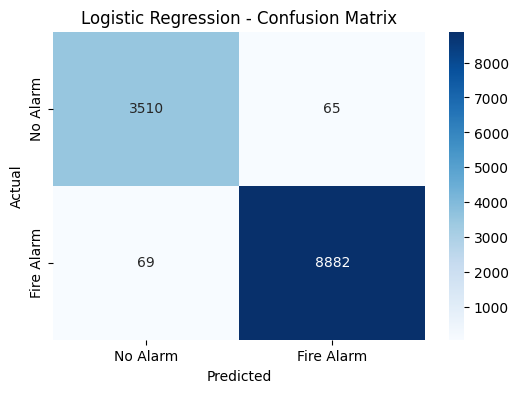

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Alarm", "Fire Alarm"],
    yticklabels=["No Alarm", "Fire Alarm"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [20]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=100,
    random_state=42
)

xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)

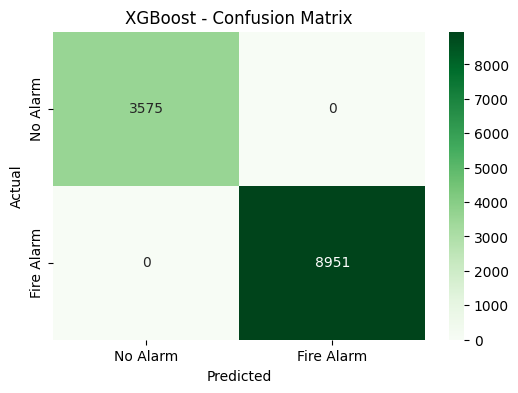

In [21]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Alarm", "Fire Alarm"],
    yticklabels=["No Alarm", "Fire Alarm"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [22]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1-score :", f1_xgb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3575
           1       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



In [23]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "Accuracy": [accuracy, accuracy_xgb],
    "Precision": [precision, precision_xgb],
    "Recall": [recall, recall_xgb],
    "F1-score": [f1, f1_xgb]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.989302,0.992735,0.992291,0.992513
1,XGBoost,1.000000,1.000000,1.000000,1.000000
